In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/processed/cleaned_data_v0.csv')
df

,Brand,CPU Mark,GPU Mark,Monitor,Width,Height,RAM,Storage Amount,OS,Weight,Price
0,HP,13144.0,1476.0,17.3,1920,1080,32.0,512.0,Windows 11,1.77,733.50
1,HP,10346.0,2690.0,15.6,1920,1080,12.0,256.0,Windows 11,1.77,886.78
2,HP,6132.0,1476.0,15.6,1920,1080,8.0,256.0,Windows 10,2.00,375.00
3,HP,2028.0,1476.0,12.5,1366,768,8.0,256.0,Windows 10,0.98,209.98
4,Lenovo,16752.0,518.0,13.0,1920,1200,16.0,256.0,Windows 10,1.19,1748.95
...,...,...,...,...,...,...,...,...,...,...,...
8454,MSI,23276.0,17089.0,16.0,2560,1600,64.0,1024.0,Windows 11,2.80,1809.00
8455,Dell,9891.0,926.0,15.6,1920,1080,32.0,1024.0,Windows 11,1.88,572.09
8456,Dell,2443.0,4253.0,13.0,1920,1080,16.0,256.0,Windows 11,0.77,999.99
8457,Lenovo,12421.0,926.0,14.0,1920,1080,16.0,256.0,Windows 10,1.77,515.00


In [16]:
# Convert "Brand" and "OS" columns to one hot encoding, with "Brand_" + column prefix
df = pd.get_dummies(df, columns=['Brand', 'OS'], prefix=['Brand', 'OS'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8459 entries, 0 to 8458
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CPU Mark         8459 non-null   float64
 1   GPU Mark         8459 non-null   float64
 2   Monitor          8459 non-null   float64
 3   Width            8459 non-null   int64  
 4   Height           8459 non-null   int64  
 5   RAM              8459 non-null   float64
 6   Storage Amount   8459 non-null   float64
 7   Weight           8459 non-null   float64
 8   Price            8459 non-null   float64
 9   Brand_Acer       8459 non-null   bool   
 10  Brand_Apple      8459 non-null   bool   
 11  Brand_Asus       8459 non-null   bool   
 12  Brand_Dell       8459 non-null   bool   
 13  Brand_HP         8459 non-null   bool   
 14  Brand_LG         8459 non-null   bool   
 15  Brand_Lenovo     8459 non-null   bool   
 16  Brand_MSI        8459 non-null   bool   
 17  Brand_Microsof

In [17]:
# Split data into train, validation, and test sets
from sklearn.model_selection import train_test_split
train_val_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1, random_state=42)  # 0.25 x 0.8 = 0.2

print(f"Train set: {train_df.shape}")
print(f"Validation set: {val_df.shape}")
print(f"Test set: {test_df.shape}")

Train set: (6851, 22)
Validation set: (762, 22)
Test set: (846, 22)


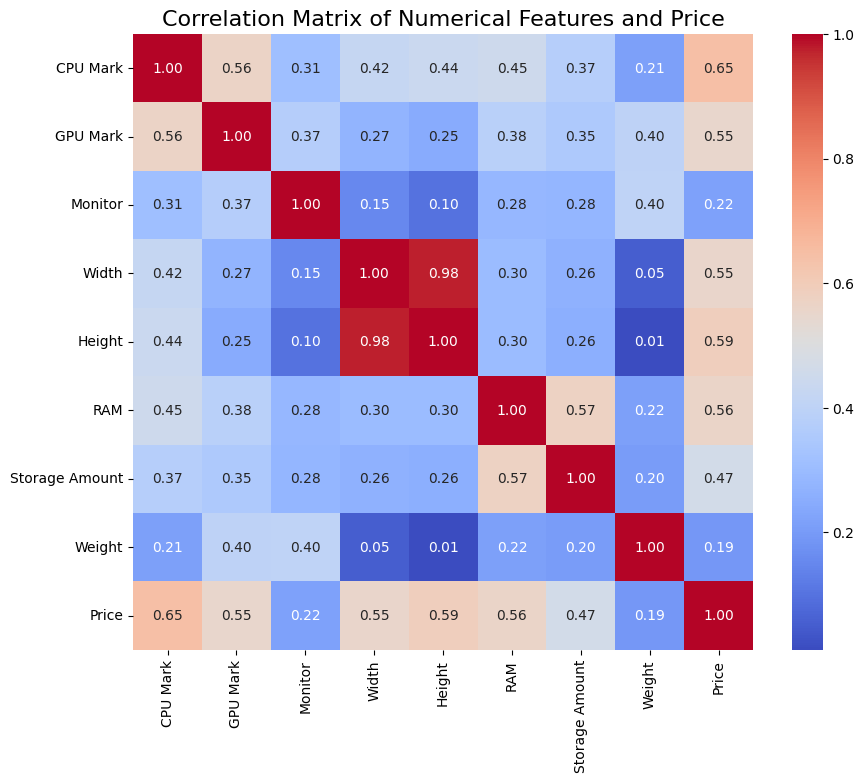

In [18]:
# Visualize coorelation between numerical features, categorical features and target variable
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('Price')  # Exclude target variable

correlation_matrix = train_df[numerical_cols + ['Price']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features and Price', fontsize=16)
plt.show()

One-hot encoded features: ['Brand_Acer', 'Brand_Apple', 'Brand_Asus', 'Brand_Dell', 'Brand_HP', 'Brand_LG', 'Brand_Lenovo', 'Brand_MSI', 'Brand_Microsoft', 'Brand_Other', 'OS_Other', 'OS_Windows 10', 'OS_Windows 11']

Correlation with Price:
Brand_Apple        0.339688
OS_Windows 10      0.087939
Brand_Dell         0.075975
Brand_MSI          0.072433
Brand_Microsoft    0.058839
Brand_LG           0.023228
Brand_Other        0.009411
OS_Windows 11     -0.005701
Brand_Asus        -0.022559
Brand_Lenovo      -0.047091
Brand_Acer        -0.105008
Brand_HP          -0.170331
OS_Other          -0.199286
Name: Price, dtype: float64




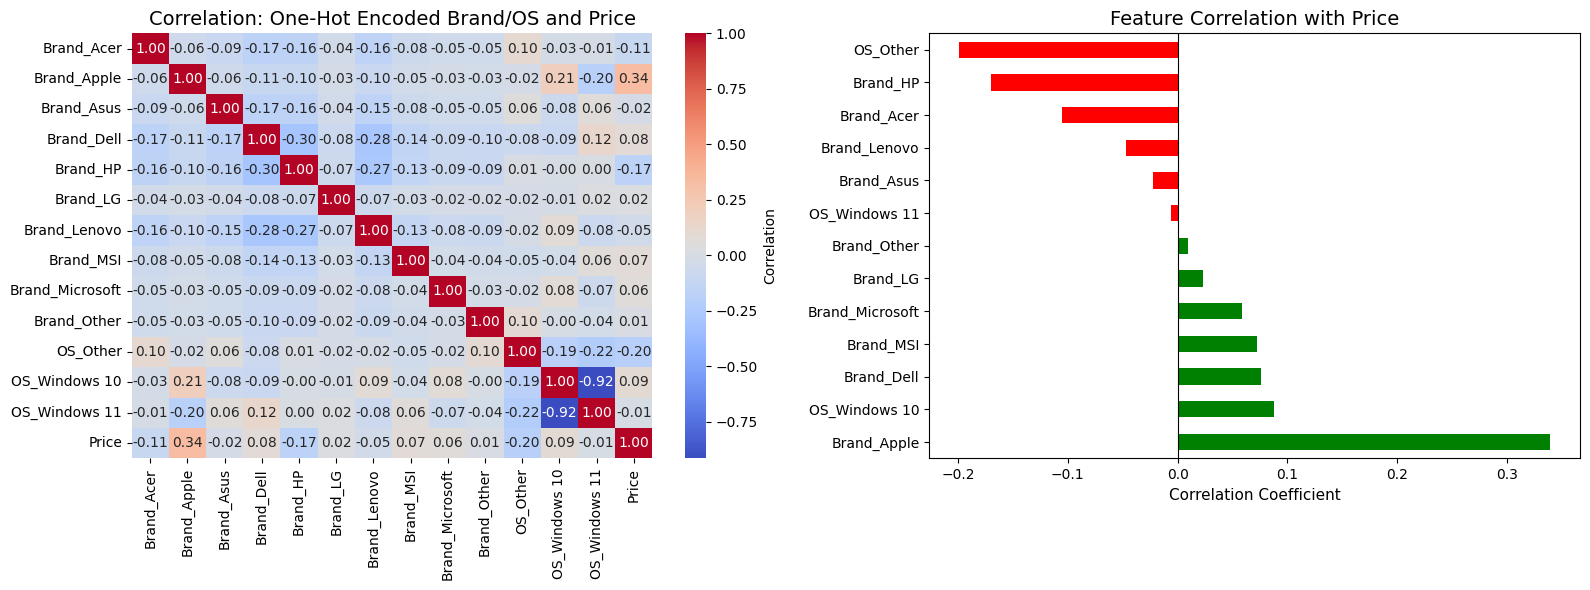


Highest positive correlation: Brand_Apple = 0.3397
Lowest correlation: OS_Other = -0.1993


In [19]:
# Visualize correlation: One-hot encoded Brand and OS with Price

# Get one-hot encoded Brand_ and OS_ columns
brand_os_cols = [col for col in train_df.columns if col.startswith('Brand_') or col.startswith('OS_')]
print(f"One-hot encoded features: {brand_os_cols}\n")

# Calculate correlation with Price
correlation_with_price = train_df[brand_os_cols + ['Price']].corr()['Price'].drop('Price').sort_values(ascending=False)
print("Correlation with Price:")
print(correlation_with_price)
print("\n")

# Visualize: Heatmap of one-hot encoded categorical features with Price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: All one-hot features with Price
corr_matrix = train_df[brand_os_cols + ['Price']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={'label': 'Correlation'}, ax=axes[0])
axes[0].set_title('Correlation: One-Hot Encoded Brand/OS and Price', fontsize=14)

# Bar plot: Correlation strength with Price
correlation_with_price.plot(kind='barh', ax=axes[1], color=['green' if x > 0 else 'red' for x in correlation_with_price.values])
axes[1].set_title('Feature Correlation with Price', fontsize=14)
axes[1].set_xlabel('Correlation Coefficient', fontsize=11)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()

print(f"\nHighest positive correlation: {correlation_with_price.idxmax()} = {correlation_with_price.max():.4f}")
print(f"Lowest correlation: {correlation_with_price.idxmin()} = {correlation_with_price.min():.4f}")

In [22]:
# Save the train, test, and validation sets to new CSV files
train_df.to_csv('../../data/processed/training/train_data_v0.csv', index=False)
val_df.to_csv('../../data/processed/training/val_data_v0.csv', index=False)
test_df.to_csv('../../data/processed/training/test_data_v0.csv', index=False)